In [ ]:
import bk_tools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau


# Import all necessary libraries for data manipulation, visualization and deep learning.

In [2]:
# Prepare the data table using the custom function from bk_tools and display its information.

df = bk_tools.prepare_data_table()
df.info()

DataFrame shape: (7909, 8)
DataFrame columns: Index(['patient_id', 'file_id', 'example', 'class', 'year', 'zoom',
       'file_path', 'is_malign'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  7909 non-null   str  
 1   file_id     7909 non-null   str  
 2   example     7909 non-null   str  
 3   class       7909 non-null   str  
 4   year        7909 non-null   int64
 5   zoom        7909 non-null   int64
 6   file_path   7909 non-null   str  
 7   is_malign   7909 non-null   int64
dtypes: int64(3), str(5)
memory usage: 494.4 KB


In [3]:
# Prepare the data splitting for the chosen zoom level (200) and display the class distribution in the validation set.
train_df_200, val_df_200, test_df_200 = bk_tools.prepare_data_splitting(df=df, chosen_zoom=200, test_val_size=0.2)
print(val_df_200["is_malign"].value_counts())



Patient split check:
64 8 9
set()
set()
set()
is_malign
1    155
0     33
Name: count, dtype: int64


In [4]:
# Define the data augmentation for the training set and the preprocessing for the validation and test sets using ImageDataGenerator.
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
)

test_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [5]:
# Create the data generators for training, validation, and testing using flow_from_dataframe.
train_generate = train_datagen.flow_from_dataframe(
    train_df_200,
    x_col="file_path",
    y_col="is_malign",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=True
)

val_generate = test_val_datagen.flow_from_dataframe(
    val_df_200,
    x_col="file_path",
    y_col="is_malign",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=False
)

test_generate = test_val_datagen.flow_from_dataframe(
    test_df_200,
    x_col="file_path",
    y_col="is_malign",
    target_size=(224, 224),
    batch_size=32,
    class_mode="raw",
    shuffle=False
)

Found 1628 validated image filenames.
Found 188 validated image filenames.
Found 197 validated image filenames.


In [6]:
# Define the model architecture using a pre-trained ResNet50 as the base and adding custom layers on top. Compile the model with an appropriate loss function, optimizer, and evaluation metrics.
def create_model():
    base_model = tf.keras.applications.ResNet50(
        weights="imagenet",
        include_top=False, 
        input_shape=(224, 224, 3)
    )

    base_model.trainable = True

    #for layer in base_model.layers[:-30]:
        #layer.trainable = False

    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ])
    
    loss= tf.keras.losses.BinaryFocalCrossentropy(
        gamma=1.5,
        apply_class_balancing=False
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=loss,
        metrics=[
            'accuracy', 
            tf.keras.metrics.Recall(name='recall'), 
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [7]:
# Create the model and print its summary to verify the architecture and the number of parameters.
my_model = create_model()
my_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,953 (90.02 MB)

 Trainable params: 23,487,617 (89.60 MB)

 Non-trainable params: 110,336 (431.00 KB)

In [ ]:
# Set up callbacks for learning rate reduction, early stopping, and model checkpointing during training.

callbacks = [
    # Reduces the learning rate by multiplying with 0.2, if validation loss not improving in 2 epochs. Minimum learning rate can go down to 1e-7
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    # If validation recall does not improve for 4 epochs, stop training and restore the best weights.
    EarlyStopping(
        monitor='val_recall', 
        patience=4,             
        mode='max', 
        restore_best_weights=True
    ),
    # Save the best model based on validation AUC during training.
    ModelCheckpoint(
        'models/best_model_binary_classification.keras',
        monitor='val_auc', 
        save_best_only=True, 
        mode='max'
    )
]

# Calculate class weights to handle class imbalance in the training data.
y_train = train_df_200["is_malign"].values.astype(int)

classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    0: weights[0],
    1: weights[1]
}

# Train the model using the fit method with the training and validation generators, class weights, and callbacks.

history = my_model.fit(
    train_generate,
    validation_data=val_generate,
    class_weight=class_weight,
    epochs=30,              
    callbacks=callbacks,
    verbose=1               
)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.7426 - auc: 0.8409 - loss: 0.2437 - precision: 0.8813 - recall: 0.7206 - val_accuracy: 0.1755 - val_auc: 0.9883 - val_loss: 1.5022 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8452 - auc: 0.9293 - loss: 0.1367 - precision: 0.9292 - recall: 0.8374 - val_accuracy: 0.1755 - val_auc: 0.8383 - val_loss: 3.3922 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8860 - auc: 0.9521 - loss: 0.1088 - precision: 0.9414 - recall: 0.8884
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757503e-05.
51/51 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.8851 - auc: 0.9553 - loss: 0.1051 - precision: 0.9418 - recall: 0.8868 - val_accuracy: 0.1755 - val_auc: 0.8664 - val_loss: 3.3350 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 609ms/step

Test Classification Report
               precision    recall  f1-score   support

   Benign (0)       1.00      0.85      0.92        75
Malignant (1)       0.92      1.00      0.96       122

     accuracy                           0.94       197
    macro avg       0.96      0.93      0.94       197
 weighted avg       0.95      0.94      0.94       197



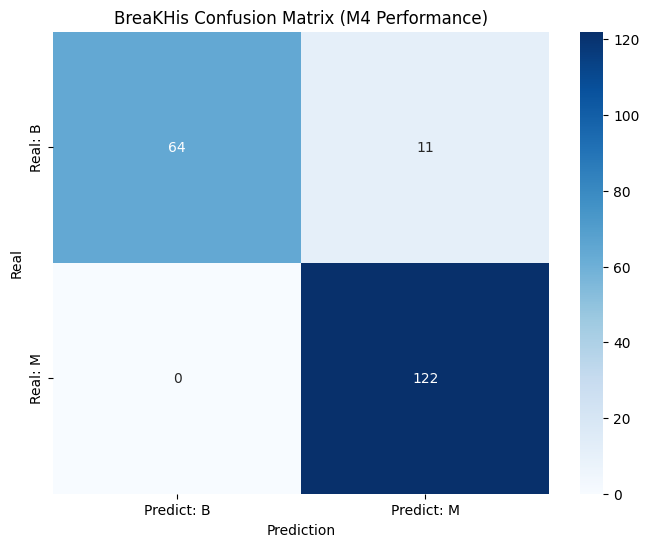

In [9]:
# Evaluate the model on the test set and print the classification report and confusion matrix.
predictions = my_model.predict(test_generate)

y_pred = (predictions > 0.5).astype(int).flatten()
y_true = test_df_200['is_malign'].values

print("\n" + "="*30)
print("Test Classification Report")
print("="*30)
print(classification_report(y_true, y_pred, target_names=['Benign (0)', 'Malignant (1)']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predict: B', 'Predict: M'], 
            yticklabels=['Real: B', 'Real: M'])
plt.title('BreaKHis Confusion Matrix (M4 Performance)')
plt.ylabel('Real')
plt.xlabel('Prediction')
plt.show()

In [10]:
# Print the minimum, maximum, and mean values of the predictions to understand the range of predicted probabilities.
print(predictions.min(), predictions.max(), predictions.mean())

2.426158e-06 0.9955453 0.6473646


In [11]:
# Print the 10th, 25th, 50th, 75th, and 90th percentiles of the predictions to understand the distribution of predicted probabilities.
print(np.percentile(predictions, [10, 25, 50, 75, 90]))

[0.02337221 0.09285966 0.90494508 0.9594211  0.98124356]


In [13]:
# Analyze the effect of different thresholds on the confusion matrix, precision, and recall by iterating through a range of threshold values and printing the corresponding metrics.
for thr in [0.15, 0.2, 0.25, 0.3, 0.35,0.4, 0.45, 0.5]:
    pred = (predictions >= thr).astype(int)
    
    from sklearn.metrics import confusion_matrix, precision_score, recall_score
    
    print(f"\nThreshold: {thr}")
    print(confusion_matrix(y_true, pred))
    print("Precision:", precision_score(y_true, pred, zero_division=0))
    print("Recall:", recall_score(y_true, pred, zero_division=0))


Threshold: 0.15
[[ 55  20]
 [  0 122]]
Precision: 0.8591549295774648
Recall: 1.0

Threshold: 0.2
[[ 60  15]
 [  0 122]]
Precision: 0.8905109489051095
Recall: 1.0

Threshold: 0.25
[[ 61  14]
 [  0 122]]
Precision: 0.8970588235294118
Recall: 1.0

Threshold: 0.3
[[ 62  13]
 [  0 122]]
Precision: 0.9037037037037037
Recall: 1.0

Threshold: 0.35
[[ 62  13]
 [  0 122]]
Precision: 0.9037037037037037
Recall: 1.0

Threshold: 0.4
[[ 63  12]
 [  0 122]]
Precision: 0.9104477611940298
Recall: 1.0

Threshold: 0.45
[[ 63  12]
 [  0 122]]
Precision: 0.9104477611940298
Recall: 1.0

Threshold: 0.5
[[ 64  11]
 [  0 122]]
Precision: 0.9172932330827067
Recall: 1.0


In [12]:
# Analyze the effect of different thresholds on the confusion matrix, precision, and recall by iterating through a range of threshold values and printing the corresponding metrics.
for thr in [0.5,0.55,0.6, 0.65, 0.7, 0.75, 0.8,0.85, 0.9]:
    pred = (predictions >= thr).astype(int)
    
    from sklearn.metrics import confusion_matrix, precision_score, recall_score
    
    print(f"\nThreshold: {thr}")
    print(confusion_matrix(y_true, pred))
    print("Precision:", precision_score(y_true, pred, zero_division=0))
    print("Recall:", recall_score(y_true, pred, zero_division=0))


Threshold: 0.5
[[ 64  11]
 [  0 122]]
Precision: 0.9172932330827067
Recall: 1.0

Threshold: 0.55
[[ 65  10]
 [  0 122]]
Precision: 0.9242424242424242
Recall: 1.0

Threshold: 0.6
[[ 66   9]
 [  0 122]]
Precision: 0.9312977099236641
Recall: 1.0

Threshold: 0.65
[[ 66   9]
 [  0 122]]
Precision: 0.9312977099236641
Recall: 1.0

Threshold: 0.7
[[ 66   9]
 [  0 122]]
Precision: 0.9312977099236641
Recall: 1.0

Threshold: 0.75
[[ 67   8]
 [  0 122]]
Precision: 0.9384615384615385
Recall: 1.0

Threshold: 0.8
[[ 70   5]
 [  3 119]]
Precision: 0.9596774193548387
Recall: 0.9754098360655737

Threshold: 0.85
[[ 72   3]
 [  8 114]]
Precision: 0.9743589743589743
Recall: 0.9344262295081968

Threshold: 0.9
[[ 74   1]
 [ 20 102]]
Precision: 0.9902912621359223
Recall: 0.8360655737704918
